# Лабораторная работа №5
## Анализ данных о фильмах с использованием Apache Spark MLlib


**Цель работы:** Расширение Spark-приложения алгоритмами машинного обучения для прогнозирования кассовых сборов и классификации фильмов по уровню дохода.

**Используемые данные:**
- `movies_metadata.csv` — метаданные фильмов (бюджет, выручка, рейтинг, жанры)
- `credits.csv` — информация об актёрах и съёмочной группе
- `ratings_small.csv` — пользовательские оценки
- `links.csv` — связи между идентификаторами IMDb и TMDb

In [ ]:
!pip install pyspark --quiet
!pip install findspark --quiet

In [ ]:
import os
import findspark
findspark.init()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks'

## Загрузка и первичная обработка данных
Создаём SparkSession, загружаем четыре датасета, приводим типы данных, парсим JSON-структуры жанров и актёров, фильтруем некорректные записи и кэшируем результаты в память

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

spark = SparkSession.builder \
    .appName("MoviesMLPrep") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

movies_raw = spark.read.csv(
    f"{DATA_DIR}/movies_metadata.csv",
    header=True,
    inferSchema=False,
    multiLine=True,
    escape='"',
    quote='"'
)

credits_raw = spark.read.csv(
    f"{DATA_DIR}/credits.csv",
    header=True,
    inferSchema=False,
    multiLine=True,
    escape='"',
    quote='"'
)

ratings = spark.read.csv(
    f"{DATA_DIR}/ratings_small.csv",
    header=True,
    inferSchema=True
)

links = spark.read.csv(
    f"{DATA_DIR}/links.csv",
    header=True,
    inferSchema=True
)

movies = movies_raw.select(
    col("id").cast("string").alias("id_str"),
    col("imdb_id"),
    col("title"),
    col("budget"),
    col("revenue"),
    col("vote_average"),
    col("vote_count"),
    col("popularity"),
    col("release_date"),
    col("runtime"),
    col("genres"),
    col("overview")
).filter(col("id_str").rlike("^\\d+$")).select(
    col("id_str").cast("long").alias("tmdbId"),
    col("imdb_id").alias("imdbId"),
    col("title").cast("string"),
    col("budget").cast("double"),
    col("revenue").cast("double"),
    col("vote_average").cast("double"),
    col("vote_count").cast("integer"),
    col("popularity").cast("double"),
    col("release_date").cast("date"),
    col("runtime").cast("double"),
    col("genres").cast("string"),
    col("overview").cast("string")
)

genre_schema = ArrayType(StructType([
    StructField("id", IntegerType(), True),
    StructField("name", StringType(), True)
]))

movies = movies.withColumn(
    "genres_parsed",
    from_json(col("genres"), genre_schema)
).withColumn(
    "genre",
    explode_outer(col("genres_parsed"))
).withColumn(
    "genre_name",
    col("genre.name")
).drop("genres_parsed", "genre")

cast_schema = ArrayType(StructType([
    StructField("name", StringType(), True),
    StructField("character", StringType(), True),
    StructField("id", IntegerType(), True)
]))

credits = credits_raw.withColumn(
    "cast_parsed",
    from_json(col("cast"), cast_schema)
).withColumn(
    "actor",
    explode_outer(col("cast_parsed"))
).select(
    col("id").cast("long").alias("tmdbId"),
    col("actor.name").alias("actor_name")
).filter(col("actor_name").isNotNull())

links = links.select(
    col("movieId").cast("int"),
    col("tmdbId").cast("long")
).dropDuplicates()

ratings = ratings.select(
    col("userId"),
    col("movieId"),
    col("rating")
)

ratings_joined = ratings.join(links, "movieId").join(movies, "tmdbId")

movies = movies.filter(
    (col("budget") > 0) &
    (col("revenue") > 0) &
    (col("vote_count") > 10) &
    col("genre_name").isNotNull()
)

movies_text = movies.filter(col("overview").isNotNull()).withColumn(
    "word_count",
    size(split(regexp_replace(col("overview"), "[^a-zA-Z\\s]", ""), "\\s+"))
).withColumn(
    "text_length",
    length(col("overview"))
).withColumn(
    "sentence_count",
    size(split(col("overview"), "[.!?]+"))
).filter(col("word_count") > 0)

movies.cache()
credits.cache()
ratings_joined.cache()
movies_text.cache()

DataFrame[tmdbId: bigint, imdbId: string, title: string, budget: double, revenue: double, vote_average: double, vote_count: int, popularity: double, release_date: date, runtime: double, genres: string, overview: string, genre_name: string, word_count: int, text_length: int, sentence_count: int]

## Подготовка датасета и конвейера признаков
Отбираем целевые колонки, удаляем пропуски, фильтруем нулевые значения и применяем логарифмическое преобразование log1p к целевой переменной для стабилизации распределения.

In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

df = movies.select(
    "tmdbId",
    "genre_name",
    "budget",
    "vote_count",
    "popularity",
    "revenue"
).dropna()

df = df.filter(
    (col("budget") > 0) &
    (col("revenue") > 0) &
    (col("vote_count") > 0)
)

indexer = StringIndexer(
    inputCol="genre_name",
    outputCol="genre_index",
    handleInvalid="skip"
)

encoder = OneHotEncoder(
    inputCols=["genre_index"],
    outputCols=["genre_vec"]
)

assembler = VectorAssembler(
    inputCols=["genre_vec", "budget", "vote_count"],
    outputCol="features_raw"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False
)

df_indexed = indexer.fit(df).transform(df)
df_encoded = encoder.fit(df_indexed).transform(df_indexed)
df_features = assembler.transform(df_encoded)
df_scaled = scaler.fit(df_features).transform(df_features)

final_df = df_scaled.select("features", col("revenue").alias("label"))

train_df, test_df = final_df.randomSplit([0.8, 0.2], seed=42)

train_df.cache()
test_df.cache()

DataFrame[features: vector, label: double]

## Построение ML-пайплайна
Настраиваем трансформеры: кодирование категориальных признаков, NLP-обработку текста (токенизация, стоп-слова, TF-IDF), объединение векторов и масштабирование.

In [ ]:
from pyspark.sql.functions import col, log1p
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

df = movies.select(
    "genre_name",
    "budget",
    "vote_count",
    "overview",
    "revenue"
).dropna()

df = df.filter(
    (col("budget") > 0) &
    (col("revenue") > 0) &
    (col("vote_count") > 0)
)

df = df.withColumn("label", log1p(col("revenue")))

indexer = StringIndexer(
    inputCol="genre_name",
    outputCol="genre_index",
    handleInvalid="skip"
)

encoder = OneHotEncoder(
    inputCols=["genre_index"],
    outputCols=["genre_vec"]
)

tokenizer = RegexTokenizer(
    inputCol="overview",
    outputCol="tokens",
    pattern="\\W"
)

remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens"
)

tf = HashingTF(
    inputCol="filtered_tokens",
    outputCol="tf_features",
    numFeatures=10000
)

idf = IDF(
    inputCol="tf_features",
    outputCol="tfidf_features"
)

assembler = VectorAssembler(
    inputCols=["genre_vec", "budget", "vote_count", "tfidf_features"],
    outputCol="features_raw"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False
)

## Обучение регрессионной модели Random Forest
Обучаем ансамблевую регрессию на 80% данных, формируем полный Pipeline и вычисляем метрики качества RMSE и R².

In [ ]:
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=10
)

pipeline = Pipeline(stages=[
    indexer,
    encoder,
    tokenizer,
    remover,
    tf,
    idf,
    assembler,
    scaler,
    rf
])

train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

model = pipeline.fit(train_df)

predictions = model.transform(test_df)

evaluator_rmse = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="rmse"
)

evaluator_r2 = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="r2"
)

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print("RMSE (log):", rmse)
print("R2:", r2)

RMSE (log): 1.5437792303240336
R2: 0.6248942411986627


In [ ]:
from pyspark.sql.functions import expm1
predictions_real = predictions.withColumn( "revenue_real", expm1(col("label")) ).withColumn( "prediction_real", expm1(col("prediction")) )
predictions_real.select("revenue_real", "prediction_real").show(10)

+--------------------+--------------------+
|        revenue_real|     prediction_real|
+--------------------+--------------------+
|                 5.0|  1048.5408194677416|
|1.1510397900000007E8|   4674928.871631106|
|1.1083448999999994E7|   843181.3858294206|
|   999999.9999999997|   844782.0301220082|
|   2100000.000000001|   676439.3073434748|
|  197.99999999999997|  200010.49788776875|
| 9.000000000000004E7|1.6233004220713237E7|
|  2000000.0000000016|  3016368.2301591574|
|1.6361885000000013E7|     3901773.2811444|
|  3499999.9999999995|  3675842.0335761723|
+--------------------+--------------------+
only showing top 10 rows


## Обратное преобразование предсказаний и расчёт MAE
Возвращаем предсказания к исходной шкале выручки через expm1(), вычисляем абсолютную ошибку и выводим MAE в долларах.

In [ ]:
from pyspark.sql.functions import abs

predictions_real = predictions_real.withColumn(
    "abs_error",
    abs(col("revenue_real") - col("prediction_real"))
)

predictions_real.selectExpr(
    "avg(abs_error) as MAE_dollars"
).show()

+-------------------+
|        MAE_dollars|
+-------------------+
|4.410523898036508E7|
+-------------------+



## Сравнительный анализ: Linear Regression vs Random Forest
Обучаем линейную регрессию с ElasticNet-регуляризацией для сравнения с нелинейной моделью и выводим сравнительные метрики.

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

lr = LinearRegression(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    maxIter=50,
    regParam=0.1,
    elasticNetParam=0.5
)

pipeline_lr = Pipeline(stages=[
    indexer,
    encoder,
    tokenizer,
    remover,
    tf,
    idf,
    assembler,
    scaler,
    lr
])

model_lr = pipeline_lr.fit(train_df)

predictions_lr = model_lr.transform(test_df)

rmse_lr = evaluator_rmse.evaluate(predictions_lr)
r2_lr = evaluator_r2.evaluate(predictions_lr)

print("LR RMSE (log):", rmse_lr)
print("LR R2:", r2_lr)

LR RMSE (log): 1.8894432017839153
LR R2: 0.43811035754211447


In [ ]:
print("=== MODEL COMPARISON ===")
print(f"Random Forest RMSE: {rmse:.4f}")
print(f"Linear Regression RMSE: {rmse_lr:.4f}")
print(f"Random Forest R2: {r2:.4f}")
print(f"Linear Regression R2: {r2_lr:.4f}")

=== MODEL COMPARISON ===
Random Forest RMSE: 1.5438
Linear Regression RMSE: 1.8894
Random Forest R2: 0.6249
Linear Regression R2: 0.4381


## Задача классификации: Разделение на классы
Вычисляем медианную выручку и формируем бинарную целевую переменную: 1 — успешный фильм (доход ≥ медианы), 0 — неуспешный.

In [ ]:
from pyspark.sql.functions import col, log1p, when
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

df = movies.select(
    "genre_name",
    "budget",
    "vote_count",
    "overview",
    "revenue"
).dropna()

df = df.filter(
    (col("budget") > 0) &
    (col("revenue") > 0) &
    (col("vote_count") > 0)
)

median_revenue = df.approxQuantile("revenue", [0.5], 0.01)[0]

df = df.withColumn(
    "label",
    when(col("revenue") >= median_revenue, 1).otherwise(0)
)

In [ ]:
indexer = StringIndexer(
    inputCol="genre_name",
    outputCol="genre_index",
    handleInvalid="skip"
)

encoder = OneHotEncoder(
    inputCols=["genre_index"],
    outputCols=["genre_vec"]
)

tokenizer = RegexTokenizer(
    inputCol="overview",
    outputCol="tokens",
    pattern="\\W"
)

remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens"
)

tf = HashingTF(
    inputCol="filtered_tokens",
    outputCol="tf_features",
    numFeatures=10000
)

idf = IDF(
    inputCol="tf_features",
    outputCol="tfidf_features"
)

assembler = VectorAssembler(
    inputCols=["genre_vec", "budget", "vote_count", "tfidf_features"],
    outputCol="features_raw"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False
)

## Обучение классификатора и оценка качества
Заменяем регрессор на RandomForestClassifier, обучаем пайплайн и оцениваем модель через AUC-ROC и Accuracy.

In [ ]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=10
)

pipeline = Pipeline(stages=[
    indexer,
    encoder,
    tokenizer,
    remover,
    tf,
    idf,
    assembler,
    scaler,
    rf
])

In [ ]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

model = pipeline.fit(train_df)

predictions = model.transform(test_df)

In [ ]:
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC"
)

evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label",
    metricName="accuracy"
)

auc = evaluator_auc.evaluate(predictions)
acc = evaluator_acc.evaluate(predictions)

print("AUC:", auc)
print("Accuracy:", acc)

AUC: 0.9106699353558357
Accuracy: 0.8239113827349122


## Визуализация ROC-кривой
Строим ROC-кривую с использованием sklearn и matplotlib для наглядной демонстрации разделяющей способности классификатора.

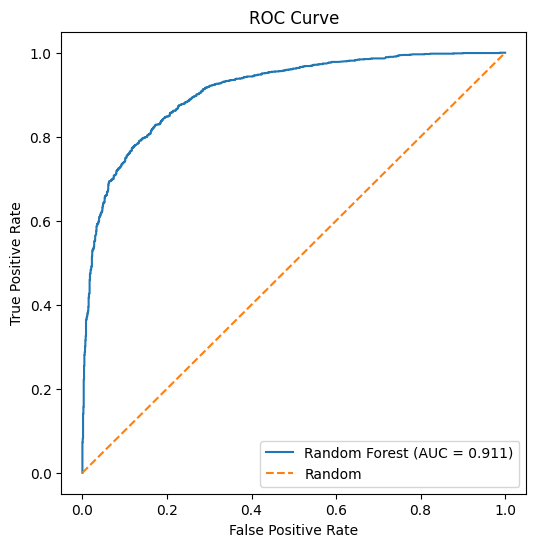

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

pdf = predictions.select("label", "probability").toPandas()

y_true = pdf["label"].values
y_score = pdf["probability"].apply(lambda x: float(x[1])).values

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],"--",label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Итоговый вывод и сравнение ЛР №4 и ЛР №5
Сравниваем подходы: в ЛР №4 выполнялся описательный анализ (агрегация, фильтрация, поиск закономерностей), а в ЛР №5 реализовано предсказательное моделирование. Использование Spark MLlib, TF-IDF и ансамблевых методов позволило получить практические модели с R² ≈ 0.62 для регрессии и AUC ≈ 0.91 для классификации, подтвердив нелинейный характер зависимостей в данных и эффективность текстовых признаков.